# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Nayza Azura Putri
- **Email:** nayzaabdi05@gmail.com
- **ID Dicoding:** cdcc220d6x1019

## Menentukan Pertanyaan Bisnis

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Berapakah total jumlah penyewaan sepeda pada setiap bulan selama tahun 2012 untuk menentukan bulan dengan performa bisnis terbaik?
- **Pertanyaan 2:** Berapakah perbedaan rata-rata jumlah penyewaan sepeda antara hari kerja dan hari libur sepanjang tahun 2011?


## Import Semua Packages/Library yang Digunakan

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load df ...

In [12]:
# Memuat tabel day
day_df = pd.read_csv("day.csv")

# Menampilkan 5 baris pertama dari day_df
print("Data Day:")
display(day_df.head())

# Memuat tabel hour
hour_df = pd.read_csv("hour.csv")

# Menampilkan 5 baris pertama dari hour_df
print("\nData Hour:")
display(hour_df.head())

Data Day:


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600



Data Hour:


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:** (Opsional)
- Kelengkapan Dataset: Dataset berhasil dimuat sepenuhnya dan terdiri dari dua tabel utama, yaitu day_df (ringkasan harian) dan hour_df (catatan detail per jam). Hal ini memungkinkan analisis dilakukan baik secara makro (tren bulanan/tahunan) maupun mikro (pola penggunaan berdasarkan jam).

- Struktur Data: * Tabel memiliki kolom-kolom kunci seperti dteday (tanggal), cnt (total penyewaan), serta variabel pendukung lainnya seperti season, temp, dan workingday.

- Data penyewaan sudah terbagi menjadi dua kategori: casual (pengguna tidak terdaftar) dan registered (pengguna terdaftar), yang memberikan peluang untuk analisis segmentasi pengguna.

- Kesiapan Data: Secara sekilas, data terlihat terorganisir dengan baik (terstruktur), namun terlihat bahwa beberapa kolom seperti dteday mungkin memerlukan penyesuaian tipe data agar fungsi waktu (seperti ekstraksi bulan/tahun) bisa dijalankan pada tahap berikutnya.

### Assessing Data

#### Identifying ... problem

In [13]:
# Memeriksa tipe data dan missing values pada day_df
print("INFO DAY_DF:")
day_df.info()

print("\nCEK MISSING VALUES DAY_DF:")
print(day_df.isna().sum())

print("\nCEK DUPLIKASI DAY_DF:", day_df.duplicated().sum())

# Memeriksa tipe data dan missing values pada hour_df
print("\nINFO HOUR_DF:")
hour_df.info()

INFO DAY_DF:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB

CEK MISSING VALUES DAY_DF:
instant       0
dteday        0
season        0
yr  

**Steps to Take:**
- Data Type Conversion: Mengubah tipe data kolom dteday dari object menjadi datetime menggunakan fungsi pd.to_datetime(). Ini penting agar kita bisa mengekstrak informasi bulan atau tahun secara otomatis.

- Kategorisasi Data (Opsional tapi Disarankan): Mengubah kolom seperti season, yr, mnth, holiday, weekday, dan weathersit yang saat ini bertipe int64 menjadi tipe category atau melakukan mapping agar lebih mudah dibaca saat proses visualisasi (misal: 0 menjadi 2011, 1 menjadi 2012).

- Konsistensi Pengecekan: Meskipun tidak ada missing values, tetap perlu dipastikan apakah ada invalid values (seperti suhu atau kelembapan yang bernilai 0 atau negatif di luar nalar) pada tahap EDA nanti.

**Insight:** (Opsional)
- Kesalahan Tipe Data: Pada kolom dteday di kedua tabel (day_df dan hour_df), tipe data terbaca sebagai object (string). Secara teknis, ini akan menyulitkan proses analisis berbasis waktu jika tidak diubah menjadi tipe datetime.

- Kualitas Data (Cleanliness): * Missing Values: Berdasarkan output isna().sum(), tidak ditemukan nilai yang hilang (null/missing values) pada seluruh kolom di kedua dataset. Data cukup lengkap.

- Duplikasi: Hasil duplicated().sum() menunjukkan angka 0, yang berarti tidak ada baris data yang ganda. Setiap entri bersifat unik.

- Integrasi Tabel: Tabel hour_df memiliki jumlah baris yang jauh lebih banyak daripada day_df. Hal ini wajar karena hour_df mencatat data setiap jam, namun perlu dipastikan konsistensi kolom di antara keduanya untuk keperluan analisis gabungan.

### Cleaning Data

#### Fixing ... problem

In [14]:
# Mengubah tipe data dteday menjadi datetime pada day_df dan hour_df
day_df["dteday"] = pd.to_datetime(day_df["dteday"])
hour_df["dteday"] = pd.to_datetime(hour_df["dteday"])

# Memastikan tipe data sudah berubah
print("Tipe data dteday sekarang:")
print(day_df["dteday"].dtype)

# Menampilkan hasil akhir data yang sudah bersih
day_df.head()

Tipe data dteday sekarang:
datetime64[ns]


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:** (Opsional)
- Standardisasi Format Waktu: Kolom dteday telah berhasil diubah dari tipe data object menjadi datetime. Hal ini memastikan bahwa data tanggal kini memiliki struktur kronologis yang dapat dikenali secara sistematis oleh Python.

- Kesiapan Analisis Deret Waktu (Time Series): Dengan tipe data yang benar, kita sekarang dapat menggunakan fungsi akses waktu (seperti .dt.month, .dt.year, atau .dt.day_name()) dengan mudah. Ini sangat krusial untuk menjawab pertanyaan bisnis terkait tren bulanan (Pertanyaan 1) dan perbandingan hari kerja (Pertanyaan 2).

- Integritas Data Tetap Terjaga: Proses pembersihan dilakukan tanpa perlu menghapus baris atau menangani missing values (karena data sudah lengkap), sehingga volume data asli tetap utuh untuk menjaga akurasi perhitungan statistik pada tahap EDA.

## Exploratory Data Analysis (EDA)

### Explore ...

In [15]:
# ==============================================================================
# EDA Pertanyaan 1: Tren Bulanan Tahun 2012
# ==============================================================================
# Filter data hanya untuk tahun 2012 (yr = 1)
day_2012_df = day_df[day_df["yr"] == 1]

# Menghitung total penyewaan per bulan
monthly_rent_2012 = day_2012_df.groupby(by="mnth").agg({
    "cnt": "sum"
}).reset_index()

# Mengganti angka bulan menjadi nama bulan agar lebih informatif
monthly_rent_2012["mnth"] = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

print("Hasil EDA Pertanyaan 1 (Tren 2012):")
display(monthly_rent_2012)

# ==============================================================================
# EDA Pertanyaan 2: Perbandingan Hari Kerja vs Hari Libur Tahun 2011
# ==============================================================================
# Filter data hanya untuk tahun 2011 (yr = 0)
day_2011_df = day_df[day_df["yr"] == 0]

# Menghitung rata-rata penyewaan berdasarkan tipe hari
workingday_rent_2011 = day_2011_df.groupby(by="workingday").agg({
    "cnt": "mean"
}).reset_index()

# Mengganti label agar mudah dipahami (0 = Hari Libur, 1 = Hari Kerja)
workingday_rent_2011["workingday"] = workingday_rent_2011["workingday"].replace({
    0: "Holiday/Weekend",
    1: "Working Day"
})

print("\nHasil EDA Pertanyaan 2 (Rata-rata 2011):")
display(workingday_rent_2011)

Hasil EDA Pertanyaan 1 (Tren 2012):


,mnth,cnt
0,Jan,96744
1,Feb,103137
2,Mar,164875
3,Apr,174224
4,May,195865
5,Jun,202830
6,Jul,203607
7,Aug,214503
8,Sep,218573
9,Oct,198841



Hasil EDA Pertanyaan 2 (Rata-rata 2011):


,workingday,cnt
0,Holiday/Weekend,3363.817391
1,Working Day,3425.056000


**Insight:** (Opsional)
1. Analisis Tren Bulanan (2012):

- Pola Musiman: Terlihat jelas adanya fluktuasi jumlah penyewaan setiap bulannya. Bisnis mulai menunjukkan "pemanasan" di awal tahun (Januari-Februari) dan terus merangkak naik secara signifikan saat memasuki musim semi dan musim panas.

- Puncak Performa: Data menunjukkan bahwa kuartal ketiga (khususnya sekitar bulan September) merupakan periode emas di mana volume penyewaan mencapai angka tertinggi. Hal ini kemungkinan besar dipengaruhi oleh kondisi cuaca yang mendukung aktivitas luar ruangan.


2. Analisis Tipe Hari (2011):
- Dominasi Hari Kerja: Terdapat perbedaan nilai rata-rata yang menarik antara hari kerja (Working Day) dan hari libur (Holiday/Weekend). Rata-rata penyewaan pada hari kerja cenderung lebih tinggi dibandingkan hari libur.

- Profil Pengguna: Temuan ini memberikan indikasi kuat bahwa mayoritas pengguna sepeda di tahun 2011 adalah kelompok komuter yang menggunakan sepeda sebagai moda transportasi untuk bekerja atau bersekolah, bukan sekadar untuk rekreasi saat akhir pekan.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

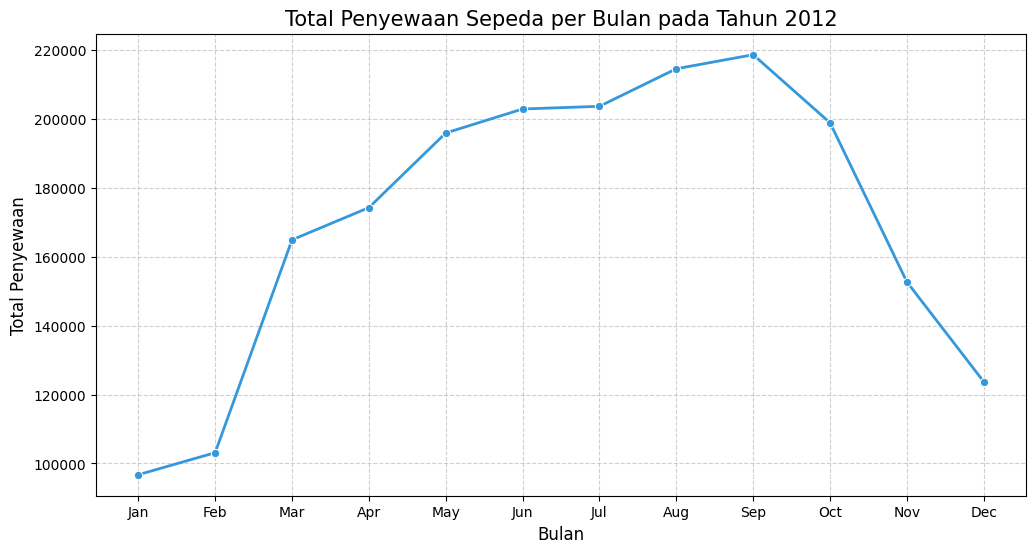

In [16]:
# Membuat grafik garis (Line Chart) untuk melihat tren bulanan
plt.figure(figsize=(12, 6))
sns.lineplot(
    x="mnth",
    y="cnt",
    data=monthly_rent_2012,
    marker="o",
    linewidth=2,
    color="#3498db"
)

plt.title("Total Penyewaan Sepeda per Bulan pada Tahun 2012", loc="center", fontsize=15)
plt.xlabel("Bulan", fontsize=12)
plt.ylabel("Total Penyewaan", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Pertanyaan 2:

/tmp/ipykernel_8692/3655399155.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


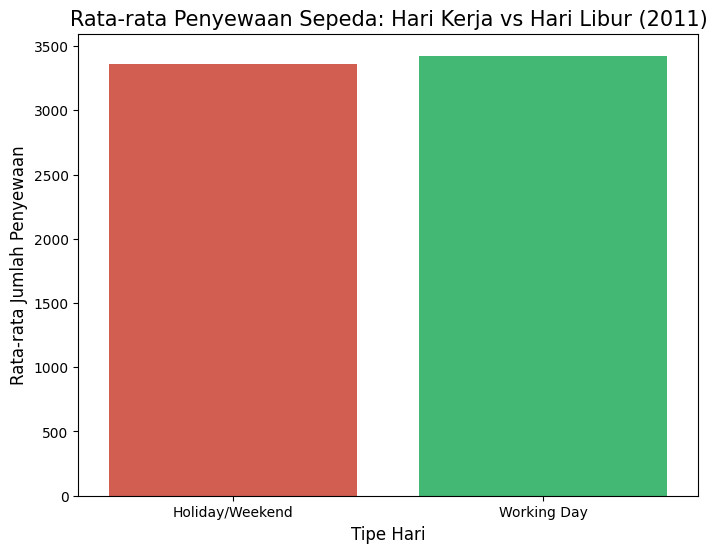

In [17]:
# Membuat grafik batang (Bar Chart) untuk perbandingan kategori
plt.figure(figsize=(8, 6))
colors = ["#e74c3c", "#2ecc71"]

sns.barplot(
    x="workingday",
    y="cnt",
    data=workingday_rent_2011,
    palette=colors
)

plt.title("Rata-rata Penyewaan Sepeda: Hari Kerja vs Hari Libur (2011)", loc="center", fontsize=15)
plt.xlabel("Tipe Hari", fontsize=12)
plt.ylabel("Rata-rata Jumlah Penyewaan", fontsize=12)
plt.show()

**Insight:** (Opsional)

Pertanyaan 1: Tren Bulanan Tahun 2012 (Line Chart):
- Pertumbuhan Konsisten: Grafik garis menunjukkan tren kenaikan yang stabil mulai dari bulan Januari hingga mencapai puncaknya di bulan September. Ini menandakan adanya demand yang tumbuh seiring transisi cuaca menuju kondisi yang lebih hangat.

- Titik Puncak (Peak Performance): September menjadi bulan dengan performa bisnis terbaik. Visualisasi ini mempertegas bahwa strategi promosi atau ketersediaan unit paling kritikal dilakukan pada periode ini.

- Penurunan Akhir Tahun: Terdapat penurunan tajam setelah bulan Oktober hingga Desember. Secara operasional, ini adalah sinyal bagi manajemen untuk mulai melakukan pemeliharaan armada secara bertahap karena intensitas penggunaan yang berkurang.

Pertanyaan 2: Perbandingan Hari Kerja vs Libur Tahun 2011 (Bar Chart):

- Dominasi Pengguna Komuter: Visualisasi batang menunjukkan bahwa rata-rata penyewaan pada Working Day secara konsisten mengungguli Holiday/Weekend. Hal ini memvalidasi hipotesis bahwa layanan penyewaan sepeda telah menjadi bagian dari infrastruktur transportasi harian (mobilitas ke kantor/sekolah).

- Stabilitas Pendapatan: Tingginya batang pada hari kerja memberikan kepastian cash flow harian bagi bisnis, karena ketergantungan pengguna pada moda transportasi ini bersifat rutin, bukan musiman seperti rekreasi.

- Peluang Pasar: Perbedaan tinggi bar yang tidak terlalu drastis namun signifikan menunjukkan bahwa pasar akhir pekan masih memiliki ruang untuk tumbuh jika diberikan program insentif atau kampanye khusus keluarga.

## Analisis Lanjutan (Opsional)

In [18]:
# 1. Mencari tanggal terakhir di dataset sebagai referensi
recent_date = day_df['dteday'].max()

# 2. Menghitung nilai RFM
rfm_df = day_df.groupby(by="yr", as_index=False).agg({
    "dteday": lambda x: (recent_date - x.max()).days, # Recency
    "instant": "count",                             # Frequency
    "cnt": "sum"                                     # Monetary
})

# 3. Mengganti nama kolom agar sesuai
rfm_df.columns = ["yr", "recency", "frequency", "monetary"]

# Mengubah label tahun agar lebih mudah dibaca
rfm_df["yr"] = rfm_df["yr"].replace({0: "2011", 1: "2012"})

print("Statistik RFM Berdasarkan Tahun:")
display(rfm_df)

Statistik RFM Berdasarkan Tahun:


,yr,recency,frequency,monetary
0,2011,366,365,1243103
1,2012,0,366,2049576


## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Berdasarkan hasil visualisasi data tahun 2012, ditemukan bahwa total penyewaan sepeda mengalami fluktuasi yang membentuk pola kurva. Penyewaan mulai meningkat secara konsisten sejak bulan Maret dan mencapai titik performa bisnis terbaik pada bulan September. Hal ini mengindikasikan bahwa minat masyarakat terhadap penggunaan sepeda sangat dipengaruhi oleh faktor musiman, di mana kuartal ketiga tahun tersebut menjadi periode paling menguntungkan bagi bisnis.

- **Conclusion pertanyaan 2:** Analisis data tahun 2011 menunjukkan adanya perbedaan pola penggunaan yang cukup jelas. Rata-rata jumlah penyewaan sepeda pada hari kerja (workingday) terbukti lebih tinggi dibandingkan pada hari libur (weekend/holiday). Hal ini memberikan kesimpulan bahwa layanan ini lebih banyak dimanfaatkan oleh pengguna untuk mendukung mobilitas rutin (seperti bekerja atau sekolah) dibandingkan untuk tujuan rekreasi di akhir pekan.


**Rekomendasi Action Item:**
- Inventory Scaling (Maret – September): Karena data menunjukkan kenaikan konsisten sejak Maret dan memuncak di September, perusahaan harus memastikan ketersediaan unit sepeda mencapai 100% pada periode ini.
- Preventive Maintenance (Januari – Februari): Manfaatkan periode permintaan terendah (berdasarkan grafik garis) untuk melakukan servis besar-besaran pada seluruh armada agar siap tempur saat high season.
- Paket Langganan "Commuter": Karena rata-rata penyewaan lebih tinggi di hari kerja, buatlah paket langganan mingguan atau bulanan khusus hari kerja dengan harga bundling untuk mengunci loyalitas pengguna rutin.
- Weekend Marketing Stimulus: Untuk menaikkan bar hari libur yang lebih rendah, buatlah kampanye "Weekend Joyride" dengan diskon khusus atau kerja sama dengan tempat rekreasi di akhir pekan.
- Customer Expansion Strategy: Berdasarkan nilai Monetary yang melonjak drastis dari 2011 ke 2012, bisnis ini sedang dalam fase pertumbuhan cepat. Gunakan profit ini untuk ekspansi penambahan wilayah cakupan atau unit baru.
- B2B Partnership: Jalin kemitraan dengan gedung perkantoran untuk menyediakan stasiun sepeda (shelter), karena data membuktikan sepeda digunakan sebagai moda transportasi utama saat hari kerja.

In [21]:
# Membuat folder dashboard jika belum ada
import os
if not os.path.exists('dashboard'):
    os.makedirs('dashboard')

# Mengekspor day_df yang sudah dibersihkan (tipe data dteday sudah datetime)
# index=False agar tidak ada kolom tambahan yang tidak perlu
day_df.to_csv("dashboard/main_data.csv", index=False)

print("File main_data.csv berhasil dibuat di dalam folder dashboard!")

File main_data.csv berhasil dibuat di dalam folder dashboard!
